# Metropolis-Within-Gibbs sampler 

In [1]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp

import blackjax

from datetime import date
rng_key = jax.random.key(int(date.today().strftime("%Y%m%d")))

In [2]:
def logdensity_fn(x, y, Sigma):
    """
    Log-pdf of ``(x, y) ~ MvNormal(0, Sigma)``.
    """
    z = jnp.concatenate([x, y])
    return jsp.stats.multivariate_normal.logpdf(
        x=z,
        mean=jnp.zeros_like(z),
        cov=Sigma
    )

# Specific example with x.shape == y.shape == (2,)
Sigma = jnp.array([
    [1., 0., .8, 0.],
    [0., 1., 0., .8],
    [.8, 0., 1., 0.],
    [0., .8, 0., 1.]
])

def logdensity(x, y):
    return logdensity_fn(x, y, Sigma=Sigma)

In [4]:
# MCMC initializers for each set of paramters
mwg_init_x = blackjax.rmh.init
mwg_init_y = blackjax.hmc.init

# MCMC updaters
mwg_step_fn_x = blackjax.rmh.build_kernel()
mwg_step_fn_y = blackjax.hmc.build_kernel()  # default integrator, etc.


def mwg_kernel(rng_key, state, parameters):
    """
    MWG kernel with RMH for ``x ~ p(x | y)`` and HMC for ``y ~ p(y | x)``.

    Parameters
    ----------
    rng_key
        The PRNG key.
    state
        Dictionary with elements `x` and `y`, where the former is an ``RMCState`` object
        and the latter is an ``HMCState`` object.
    parameters
        Dictionary with elements `x` and `y`, each of which is a dictionary of the parameters
        to the corresponding algorithm's ``step_fn()``.

    Returns
    -------
    Dictionary containing the updated ``state``.
    """
    rng_key_x, rng_key_y = jax.random.split(rng_key, num=2)

    # avoid modifying argument state as JAX functions should be pure
    state = state.copy()

    # mutating structures are not supported by JAX. Hence the copy above. 

    # --- update for x ---
    # conditional logdensity of x given y
    def logdensity_x(x): return logdensity(x=x, y=state["y"].position)

    # give state["x"] the right log_density
    state["x"] = mwg_init_x(
        position=state["x"].position,
        logdensity_fn=logdensity_x
    )
    # update state["x"]    
    state["x"], _ = mwg_step_fn_x(
        rng_key=rng_key_x,
        state=state["x"],
        logdensity_fn=logdensity_x,
        **parameters["x"]
    )

    # --- update for y ---
    # conditional logdensity of y given x
    def logdensity_y(y): return logdensity(y=y, x=state["x"].position)

    # give state["y"] the right log_density
    state["y"] = mwg_init_y(
        position=state["y"].position,
        logdensity_fn=logdensity_y
    )
    # update state["y"]
    state["y"], _ = mwg_step_fn_y(
        rng_key=rng_key_y,
        state=state["y"],
        logdensity_fn=logdensity_y,
        **parameters["y"]
    )

    return state

In [5]:
parameters = {
    "x": {
        "transition_generator": blackjax.mcmc.random_walk.normal(.2 * jnp.eye(2))
    },
    "y": {
        "inverse_mass_matrix": jnp.array([1., 1.]),
        "num_integration_steps": 100,
        "step_size": 1e-2
    }
}

In [6]:
initial_state = {
    "x": mwg_init_x(
        position=jnp.array([0., 0.]),
        logdensity_fn=lambda x: logdensity(x=x, y=jnp.array([0., 0.]))
    ),
    "y": mwg_init_y(
        position=jnp.array([0., 0.]),
        logdensity_fn=lambda y: logdensity(y=y, x=jnp.array([0., 0.]))
    )
}

In [8]:
def sampling_loop(rng_key, initial_state, parameters, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state = mwg_kernel(
            rng_key=rng_key,
            state=state,
            parameters=parameters
        )
        positions = {k: state[k].position for k in state.keys()}
        return state, positions

    keys = jax.random.split(rng_key, num_samples)
    _, positions = jax.lax.scan(one_step, initial_state, keys)

    return positions

In [9]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


In [10]:
%%time
rng_key, sample_key = jax.random.split(rng_key)
positions = sampling_loop(sample_key, initial_state, parameters, 10_000)

CPU times: user 27 s, sys: 31 ms, total: 27.1 s
Wall time: 27.1 s


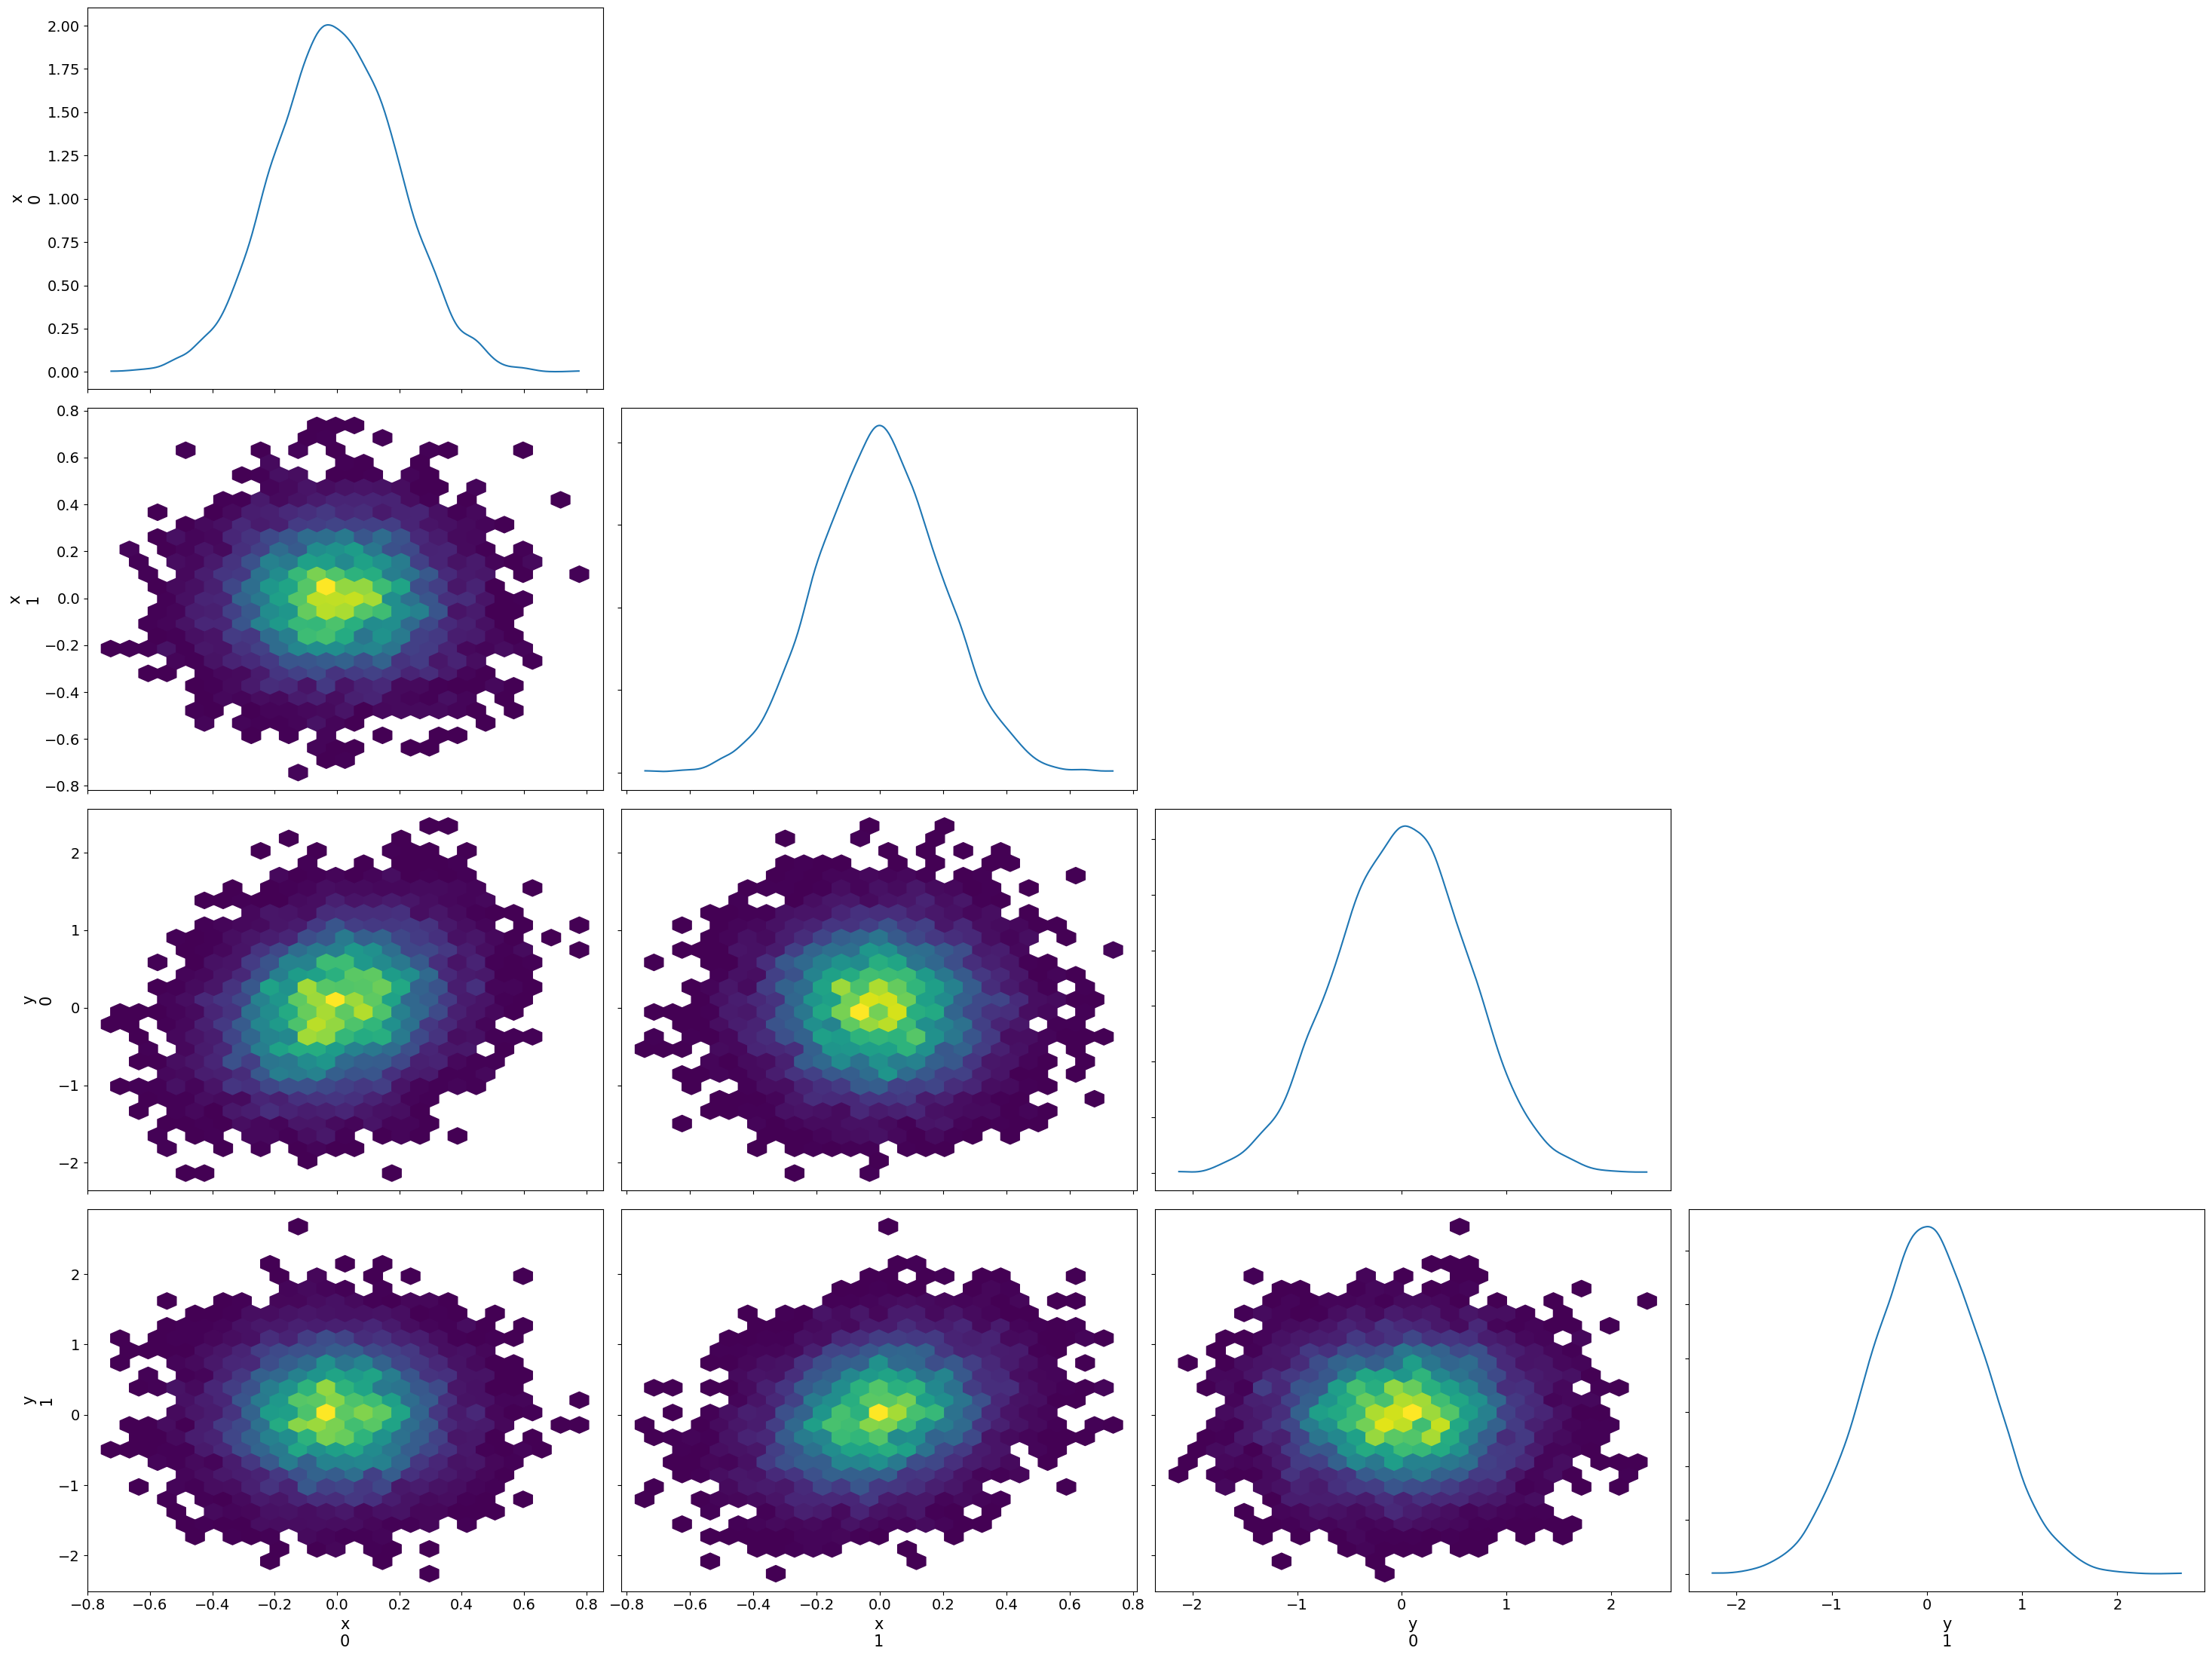

In [11]:
import matplotlib.pyplot as plt
import arviz as az

idata = az.from_dict(posterior={k: v[None, ...] for k, v in positions.items()})
az.plot_pair(idata, kind='hexbin', marginals=True)
plt.tight_layout();